# ***Key Terms for Estimates of Location***

- Mean
- Weighted Mean
- Median
- Percentile
- Weighted Median
- Trimmed Mean
- Trimmed Median
- Robust
- Outliner 

In [55]:
import numpy as np 
import scipy as sy
import pandas as pd 
import matplotlib.pyplot as plt 
import wquantiles
import math
import seaborn as sns

# Robust --> not effected by Outliners eg -> Median , Trimmed Mean(Mean but outliner is removed)

# Outliners --> The extreme values .


In [5]:
# dataset

my_data={"state":["Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware"],"Population":[4779736,710231,6392017,2915918,37253956,5029196,3574097,897934],"Murder rate":[5.7,5.6,4.7,5.6,4.4,2.8,2.4,5.8]}
data=pd.DataFrame(my_data)

data

,state,Population,Murder rate
0,Alabama,4779736,5.7
1,Alaska,710231,5.6
2,Arizona,6392017,4.7
3,Arkansas,2915918,5.6
4,California,37253956,4.4
5,Colorado,5029196,2.8
6,Connecticut,3574097,2.4
7,Delaware,897934,5.8


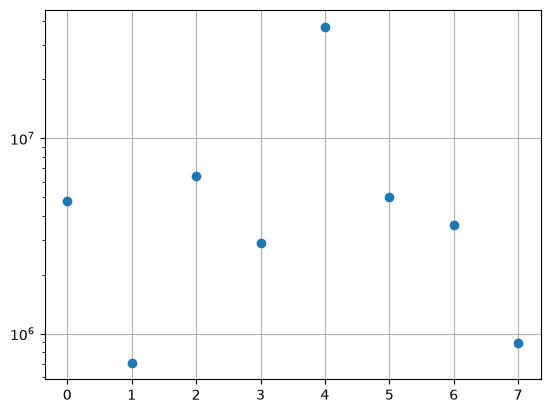

In [8]:
plt.semilogy(data["Population"],'o')

plt.grid()
plt.show()

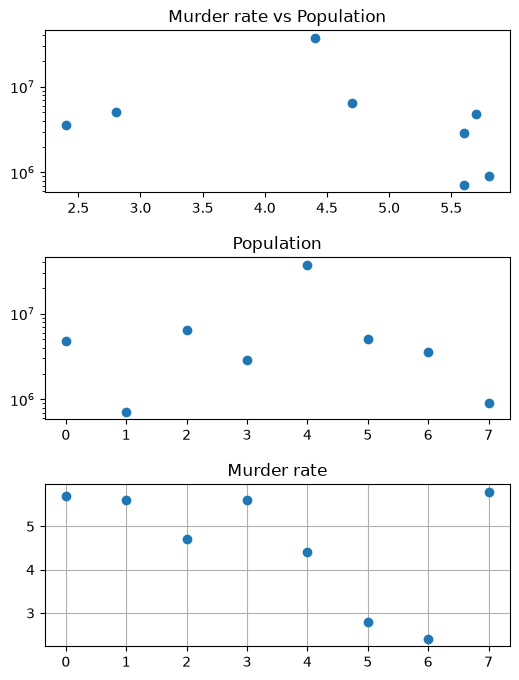

In [13]:
# plot of everything 

fig,axs = plt.subplots(3,1,figsize=(6,8))

axs[0].semilogy(data["Murder rate"],data["Population"],"o")
axs[0].set_title("Murder rate vs Population")

axs[1].semilogy(data["Population"],"o")
axs[1].set_title("Population")

axs[2].plot(data["Murder rate"],"o")
axs[2].set_title("Murder rate")

plt.subplots_adjust(hspace=0.4) 
plt.grid()
plt.show()

In [25]:
# Mean 
print(f"The Mean is {data["Population"].mean()}\n")

# trimmed-mean 
print(f"The trimmed Mean {sy.stats.trim_mean(data["Population"],0.15)}\n")
# syntax for trim_mean is scipy.stats.trim_mean(column,value)  value holdes how much you want to trim.

# median 
print(f"The Median is {data["Population"].median()}\n")

# Weighted mean
weighted_mean= np.average(data["Population"], weights=data["Murder rate"])
print(f"The Weighted mean is {weighted_mean}\n")

weighted_median = wquantiles.median(data['Murder rate'], weights=data['Population'])
weighted_median1 = wquantiles.median(data["Population"], weights = data["Murder rate"])
print(f"The weighted median is {weighted_median} and {weighted_median1}\n")

The Mean is 7694135.625

The trimmed Mean 3931483.0

The Median is 4176916.5

The Weighted mean is 7280497.694594596

The weighted median is 4.448750497554494 and 3663403.592592593



## ***Key Terms for Variability Metrics***

- deviation
- Variance
- Standar Variance
- Mean absolute deviation
- Mean absolute deviation for median
- Range
- order Statistics
- Percentile
- Interquartile range or IQR

In [27]:
# Avg of how far are values from mean
deviation = 0 
for i in data["Population"]:
    deviation = i - data["Population"].mean()

print(deviation/len(data["Population"])-1)

-849526.203125


In [28]:
# variance

var=np.var(data["Population"])
print(f"Variance is {var}")

Variance is 128230435522129.22


In [30]:
# standard variance

stdvar=math.sqrt(var)
print(f"The standard variance is {stdvar}")

The standard variance is 11323887.827161184


In [31]:
# mean absolute is nothing but deviation where (x-xMean) is taken absolute (no negative).

# range is difference of Highest value and lowest value.

ranged = max(data["Population"])-min(data["Population"])
print(f"The range is {ranged}")

The range is 36543725


In [34]:
# Ordered Statistics values from smallest to largest 
os = sorted(data["Population"])
os

[710231, 897934, 2915918, 3574097, 4779736, 5029196, 6392017, 37253956]

## percentile gives the measure the number of people ahead of given number 

## Interquartile range is difference 75th percentile and the 25th percentile

## ***Key Terms for Exploring the Distribution***

- Boxplot
- Frequency table
- Histogram
- Density plot

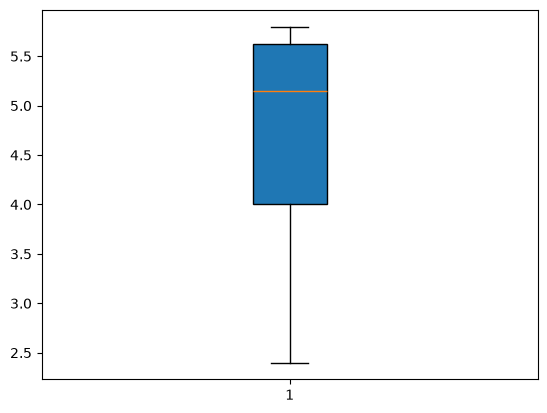

In [39]:
# boxplot 

plt.boxplot(data1["Murder rate"],patch_artist=True) 
plt.show()

# box plot help us visualize 5 metrics  minimum, first quartile (Q1), median, third quartile (Q3), and maximum. 

```
1)Box plot: The rectangle filled box represent 50% of middel population of data.
2)The lower end of the rectangle box represent Q1 i.e 25percentile. 
3)The upper end of the rectangle box represent Q3 i.e 75percentile.
4)The orange line here represent Median of the data.
5)There is also a dotted line representing the median (Not present in this plot).
6)The bottom most line of this plot represent the minimum value. 
7)the top most line of this plot represent the maximum value.
```

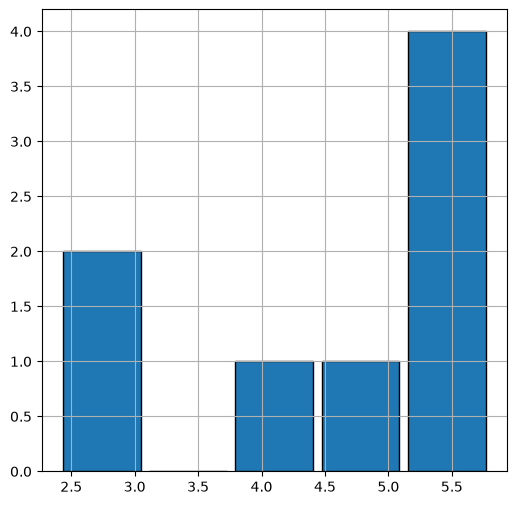

In [54]:
data["Murder rate"].hist(bins=5, figsize=(6, 6),edgecolor='black',rwidth=0.9)
plt.show()

```
1)Histogram at start can be confusing so let's visualize it:

a) Y-axis shows the count of numbers that fall in the given range of histogram-bar i.e btw ~2.4 to ~ 3.1 there lies two values which is true as there is 2.4 and 2.8 in our data.

b) Important parameter in plt.hist() is bins and edgecolor(for visualization) 
        (needed)bins represent how wide is the bar in histogram.
        edgecolor is color of edge of different bars in graph 
        (option)rwidth is  width between each bars
```

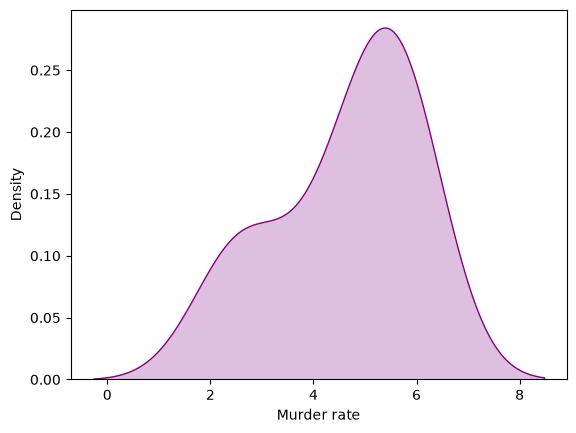

In [57]:
sns.kdeplot(data["Murder rate"], fill=True, color='purple')
plt.show()

In [ ]:
# Today i don't understand the visualization of density plot but tomorrow i will :) 

In [59]:
# percentiles 

pet=data['Murder rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
pet

0.05    2.540
0.25    4.000
0.50    5.150
0.75    5.625
0.95    5.765
Name: Murder rate, dtype: float64

In [61]:
# we can get somethings similar result for overall dataset i.e :-

data.describe()

,Population,Murder rate
count,8.000000e+00,8.000000
mean,7.694136e+06,4.625000
std,1.210575e+07,1.350926
min,7.102310e+05,2.400000
25%,2.411422e+06,4.000000
50%,4.176916e+06,5.150000
75%,5.369901e+06,5.625000
max,3.725396e+07,5.800000
